In [1]:
# Step 1: Install Libraries (only once)
!pip install pandas nltk textblob matplotlib seaborn emoji wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.6 MB/s eta 0:00:00


In [24]:
# Step 2: Import Libraries
import pandas as pd
import nltk
import re
import emoji
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Step 3: Load Dataset
data = pd.read_csv("tweets.csv", header=None, names=['sentiment', 'id', 'date', 'query', 'user', 'tweet'])
print(data.head())

   sentiment  id                          date    query      user  \
0          4   3  Mon May 11 03:17:40 UTC 2009  kindle2    tpryan   
1          4   4  Mon May 11 03:18:03 UTC 2009  kindle2    vcu451   
2          4   5  Mon May 11 03:18:54 UTC 2009  kindle2    chadfu   
3          4   6  Mon May 11 03:19:04 UTC 2009  kindle2     SIX15   
4          4   7  Mon May 11 03:21:41 UTC 2009  kindle2  yamarama   

                                               tweet  
0  @stellargirl I loooooooovvvvvveee my Kindle2. ...  
1  Reading my kindle2...  Love it... Lee childs i...  
2  Ok, first assesment of the #kindle2 ...it fuck...  
3  @kenburbary You'll love your Kindle2. I've had...  
4  @mikefish  Fair enough. But i have the Kindle2...  


In [18]:
# Step 4: Create a Custom Slang Dictionary
slang_dict = {
    "lol": "laughing out loud",
    "omg": "oh my god",
    "idk": "i do not know",
    "btw": "by the way",
    "thx": "thanks",
    "luv": "love",
    "gr8": "great",
    "smh": "shaking my head",
    "b4": "before",
    "u": "you",
    "Ive":"i have"
}

In [19]:
# Step 5: Clean Tweets (handling emojis, hashtags, and slang)

def clean_tweet(tweet):
    # Convert emojis to text
    tweet = emoji.demojize(tweet, delimiters=(" ", " "))

    # Remove URLs, mentions, and hashtags (keep hashtag text)
    tweet = re.sub(r'http\S+|www\S+|@\w+', '', tweet)
    tweet = re.sub(r'#', '', tweet)

    # Remove numbers and punctuation
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet)

    # Lowercase the tweet
    tweet = tweet.lower()

    # Replace slang words using dictionary
    words = tweet.split()
    tweet = ' '.join([slang_dict.get(word, word) for word in words])

    # Remove stopwords
    tweet = ' '.join(word for word in tweet.split() if word not in stop_words)

    return tweet

data['clean_tweet'] = data['tweet'].astype(str).apply(clean_tweet)
data[['tweet', 'clean_tweet']].head()


,tweet,clean_tweet
0,@stellargirl I loooooooovvvvvveee my Kindle2. ...,loooooooovvvvvveee kindle dx cool fantastic right
1,Reading my kindle2... Love it... Lee childs i...,reading kindle love lee childs good read
2,"Ok, first assesment of the #kindle2 ...it fuck...",ok first assesment kindle fucking rocks
3,@kenburbary You'll love your Kindle2. I've had...,youll love kindle ive mine months never looked...
4,@mikefish Fair enough. But i have the Kindle2...,fair enough kindle think perfect


In [20]:
# Step 6: Sentiment Analysis using TextBlob
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

data['sentiment'] = data['clean_tweet'].apply(get_sentiment)
data[['clean_tweet', 'sentiment']].head()


,clean_tweet,sentiment
0,loooooooovvvvvveee kindle dx cool fantastic right,Positive
1,reading kindle love lee childs good read,Positive
2,ok first assesment kindle fucking rocks,Positive
3,youll love kindle ive mine months never looked...,Positive
4,fair enough kindle think perfect,Positive


/tmp/ipython-input-4112063784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='coolwarm')


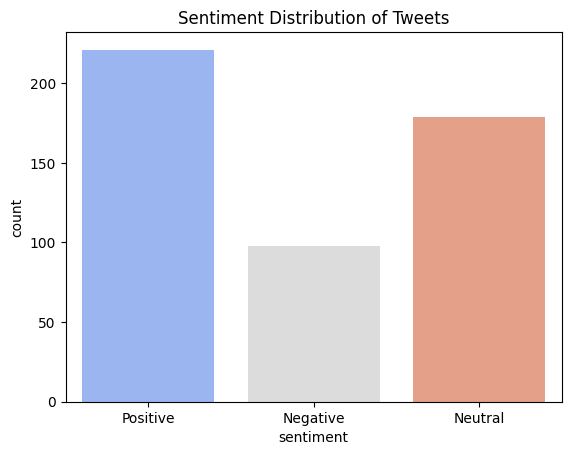

In [21]:
# Step 7: Visualize Sentiment Distribution
sns.countplot(x='sentiment', data=data, palette='coolwarm')
plt.title("Sentiment Distribution of Tweets")
plt.show()


In [23]:
# Step 9: Save Final Output
data.to_csv("twitter_sentiment_output.csv", index=False)
print("✅ Sentiment results saved to twitter_sentiment_output.csv")


✅ Sentiment results saved to twitter_sentiment_output.csv
